In [1]:
import bs4 as bs
import requests
import pandas as pd
import datetime
import numpy as np
from geopy.geocoders import Nominatim
import gspread
from oauth2client.service_account import ServiceAccountCredentials

In [52]:
headers = {
    "authority": "www.funda.nl",
    "accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
    "accept-language": "de-DE,de;q=0.9,en-US;q=0.8,en;q=0.7,tr;q=0.6,hu;q=0.5",
    "cache-control": "no-cache",
    "pragma": "no-cache",
    "priority": "u=0, i",
    "referer": "https://www.funda.nl/en/",
    "sec-ch-ua": '"Chromium";v="146", "Not-A.Brand";v="24", "Google Chrome";v="146"',
    "sec-ch-ua-mobile": "?1",
    "sec-ch-ua-platform": '"Android"',
    "sec-fetch-dest": "document",
    "sec-fetch-mode": "navigate",
    "sec-fetch-site": "same-origin",
    "sec-fetch-user": "?1",
    "upgrade-insecure-requests": "1",
    "user-agent": "Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Mobile Safari/537.36",
}

# headers = { "authority": "www.funda.nl",
# "method": "GET",
# "path": "/en/zoeken/koop?selected_area=[%22nl%22]",
# "scheme": "https",
# "accept" : "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
# "accept-encoding" : "gzip, deflate, br, zstd",
# "accept-language" : "de-DE,de;q=0.9,en-US;q=0.8,en;q=0.7,tr;q=0.6",
# "no-cache" : "cache-control",
# "cookie" : "didomi_consent=functional-group,analytical-group,; SNLB=24204f7050db431c; .ASPXANONYMOUS=Q-9kU6OuVgiLGhggJv-mPjsdNVWvq0ExRIEh6gux_A1eMPulB9wnt_jIRAnlbj1IxF0X682OQVPL8Lj7KqO6DcXgEjT9Abcrr076Pm3EgYZ0wQDizlmbi_uWRzt7lDYNgYpE5qpm9ckJno15imP2cCVkDVA1; didomi_token=eyJ1c2VyX2lkIjoiMTk0ZTUyNDQtMGJhZi02MTQyLThhODktOTU2ZmM4NTgzMzI5IiwiY3JlYXRlZCI6IjIwMjUtMDItMDhUMTA6Mzk6MDUuOTE0WiIsInVwZGF0ZWQiOiIyMDI1LTAyLTA4VDEwOjM5OjA3LjUzOFoiLCJ2ZW5kb3JzIjp7ImRpc2FibGVkIjpbImdvb2dsZSIsImM6ZnVuZGFmdW5jLUFIaEQyWXEzIiwiYzpzZWdtZW50LUdRcFdQUWhLIiwiYzpmdW5kYXBhcnQtaUJOZ1hXd1giLCJjOmRhdGFkb2ctcmR0WTdBbUUiLCJjOmdvb2dsZWFuYS1qYWduNk5uZyIsImM6b3B0aW1pemVseS04MjJBNnFOZyIsImM6Y2xvdWRmbGFyZS04Zm5hM0VIQSIsImM6Z29vZ2xldGFnLWVFWVBqMzJaIiwiYzpob3RqYXItVDgyanRDVXEiLCJjOmdldGZlZWRiYS1CdGpYRkwyWiIsImM6c2FsZXNmb3JjZS1rSzdycGV4WSIsImM6aW5nLWpxWDZkM3RZIl19LCJwdXJwb3NlcyI6eyJkaXNhYmxlZCI6WyJwZXJzb25hbGlzYXRpb24tZ3JvdXAiLCJhZHZlcnRpc2VtZW50LWdyb3VwIl19LCJ2ZXJzaW9uIjoyLCJhYyI6IkFBQUEuQUFBQSJ9; euconsent-v2=CQMgjEAQMgjEAAHABBENBbFgAAAAAAAAABpYAAAAAADEAAMAAQVlJQAYAAgrKUgAwABBWUdABgACCsoSADAAEFZS0AGAAIKygAAA.YAAAAAAAAAAA; ajs_anonymous_id=00000000-0000-0000-0000-000000000000; bm_mi=00F25F336CE9A0EE0E4BCF2A6C38DF1A~YAAQT/IWAr4rjpiUAQAALUMk5RopqL/eYUvz9NBn23b6MeHZozHs6zSjK+dv63BodDpo/2hFkW7CMdvbVwtRPN1v3l75rEd9PcYfv9DO1VHzSNjhvSCDw0sVWx0uYqzrqWBws+cLBUaYRL9OPI8xO+V+F+j0TBqCuhbciizdN4QySRFutotD6wdNeUi/S8R1FwRORXVfzHXCxm6yBydsQ+h/o6eNkiwmxAMg1YjNnzA2DE1REc7GHRsJSw9gkkSLjxK8H3V+X1+6QTkdeZsaVk0/wzzsHbbIW9rbntbutlTd/deNlwuLeF04LofQv6U=~1; ak_bmsc=4D52DCE03720F085F9D7101E3CFEC957~000000000000000000000000000000~YAAQT/IWAsYrjpiUAQAA0EYk5RrgRbPaTEubeAJ2cXgTtcG9quhJXjl9zWvXnj7x3wNXOx+qoeLwKhUp7v8EMEfCXTmHK0WrDrzPfBYW4ip7nX7dhLMyOhyRODHzCm6Ve59+Ym1ZmnfB0JQeeumI3YJAyNCxxtNKvR+QpyN1bS1MyuexJN9EX3JIQJomNpw+Ou8rpV8TpK9kj/cL2323RhrNDndzDQpSmRXXU6jELNwOSwlAFWzgFGb/Vrjd2MTjRPijuEOPdmgoZ9J9egUaVjInI8Czj/snZJjeMYwpvKlHAkFkLSk5xsTwc4BOShyGgqT5ucH0HZn0+G+Nvjw80FeDqyxxDWlTfmiLNYrP1UALxkISikELtVoAjRbPr/kyy5rJQNy4OY0dJDsD9uOiFXIbbWVgirCmD8AwoGaZ/J+uHtm0sdnhAUE9/VScodOnU9GaL9QpX4Pyo4Fn7brERXyuyTO41JcaK5U+t08ukaPUtw==; optimizelyEndUserId=oeu1739011153005r0.3104013091199771; wib=koop%3Dprovincie-noord-holland; html-classes=js supports-placeholder; _ga=GA1.1.1221458321.1739011442; fonts-loaded=true; _ga_DK6XS655BS=GS1.1.1739011441.1.0.1739011442.0.0.0; bm_sv=72B3CD704C0051A61F16D38BB4E79951~YAAQhfIWAlrL09yUAQAAM8Mo5Rr6p8LfhKYllOCdMFNRfBcwuwD8TZrcBkKDFvSFBB+0VzaHoL0LIju/zmIwNaE792G0sIliAS35xZi3Raxc68W+sRTvjOLsFpU5if8Bff2ND4z9vyouapnZHU7Vreul6YCf4ipHcXRqxBBvMKozr3Q+MgtWWo8ffUDHL9oF88QHgzo+lnXzIZ6BE2fZoakhbdfHL3+2qDRNoDg3hMP3lE8rBLK8SWsNXFvJm0I=~1; _ga_WLRNSHBY8J=GS1.1.1739011441.1.0.1739011442.0.0.0; last_search=koop%3DNederland%2520%252B%25200%2520filter%7CL2VuL3pvZWtlbi9rb29wP3NlbGVjdGVkX2FyZWE9JTVCJTIybmwlMjIlNUQ%3D; optimizelySession=1739011446976; _dd_s=logs=1&id=b35d8833-11e2-4009-99aa-d244dc66f2a0&created=1739011145631&expire=1739012343872",
# "pragma" : "no-cache",
# "priority" : "u=0, i",
# "sec-ch-ua" : '"Not(A:Brand";v="99", "Google Chrome";v="133", "Chromium";v="133"',
# "sec-ch-ua-mobile" : "?0",
# "sec-ch-ua-platform" : '"Windows"',
# "sec-fetch-dest" : "document",
# "sec-fest-mode" : "navigate",
# "sec-fetch-site" : "same-origin",
# "sec-fetch-user" : "?1",
# "upgrade-insecure-requests" : "1",
# "user-agent" : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/133.0.0.0 Safari/537.36"
# }

#headers = random.choice(headers_list)
province = "provincie-drenthe"

params = {"selected_area" : f'["{province}"]',
            "object_type" : '["house", "apartment"]',
            "floor_area" : '',
            "rooms" : '',
            "sort" : "date_down",
            "search_result" : "1"}

#Find the last page's number
url = f"https://www.funda.nl/en/zoeken/koop"

final_list = []

# for page in range(1,last_page+2,1):
for page in range(1,2,1):
    print(f"province: {province}, page number: {str(page)}")
    params["search_result"] = str(page)
    r = requests.get(url, params=params, headers=headers)

    if r.status_code == 200:
        soup = bs.BeautifulSoup(r.text, "lxml")
        divs = soup.find_all('div', class_='@container border-b pb-3')

        if not divs:
            print(f"unsuccessful to parse page: {str(page)}")
            break

        for div in divs:
            if len(div.contents) > 0:

                link = div.find("a")["href"]
                title = div.find("span", {"class" : "truncate"}).text.strip()
                postal = div.find("div", {"class" : "truncate text-neutral-80"}).text.strip()
                price = div.find("div", {"class" : "mt-2"}).text.strip()
                details = [ li.text.strip() for li in div.findAll("ul")[-1].findAll("li")]
                image = div.find("img")["srcset"] if div.find("img") else None

                final_list.append({"url" : link,
                                "title" : title,
                                "postal_raw" : postal,
                                "price_raw" : price,
                                "details"  : details,
                                "image" : image})

    else:
        print(f"unsuccesful to parse page: {str(page)}")

df = pd.DataFrame(final_list)
df

province: provincie-drenthe, page number: 1


,url,title,postal_raw,price_raw,details,image
0,/en/detail/koop/emmen/huis-loo-ackers-10/43303...,Loo-ackers 10,7824 NK Emmen,"€ 250,000 k.k.93 m²279 m²2D","[93 m², 279 m², 2, D]",https://cloud.funda.nl/tiara-media/06873c39-67...
1,/en/detail/koop/benneveld/huis-bennevelderstra...,Bennevelderstraat 18,7856 TB Benneveld,"€ 545,000 k.k.118 m²2,745 m²3E","[118 m², 2,745 m², 3, E]",https://cloud.funda.nl/tiara-media/3df60803-48...
2,/en/detail/koop/noordscheschut/huis-hoveniersl...,Hoveniersland 28,7914 PT Noordscheschut,"€ 525,000 k.k.129 m²491 m²4A","[129 m², 491 m², 4, A]",https://cloud.funda.nl/tiara-media/44dfabf0-01...
3,/en/detail/koop/roden/huis-ons-thuis-in-roden-...,Ons thuis in Roden -Rijwoning Wilhelminastr (B...,9301 LS Roden,"€ 484,000 v.o.n.128 m²136 m²4A+++","[128 m², 136 m², 4, A+++]",https://cloud.funda.nl/tiara-media/72bac8fd-53...
4,/en/detail/koop/roden/huis-ons-thuis-in-roden-...,Ons thuis in Roden -Rijwoning Wilhelminastr (B...,9301 LS Roden,"€ 478,000 v.o.n.128 m²128 m²4A+++","[128 m², 128 m², 4, A+++]",https://cloud.funda.nl/tiara-media/8a6f3e53-46...
5,/en/detail/koop/roden/huis-ons-thuis-in-roden-...,Ons thuis in Roden -Rijwoning Wilhelminastr (B...,9301 LS Roden,"€ 484,000 v.o.n.128 m²136 m²4A+++","[128 m², 136 m², 4, A+++]",https://cloud.funda.nl/valentina_media/227/153...
6,/en/detail/koop/roden/huis-ons-thuis-in-roden-...,Ons thuis in Roden - Rijwoning Kanaalstraat (B...,9301 LS Roden,"€ 497,000 v.o.n.145 m²133 m²4A+++","[145 m², 133 m², 4, A+++]",https://cloud.funda.nl/tiara-media/de25d924-99...
7,/en/detail/koop/roden/huis-ons-thuis-in-roden-...,Ons thuis in Roden - Rijwoning Trambaan (Bouwn...,9301 LS Roden,"€ 458,000 v.o.n.113 m²134 m²3A+++","[113 m², 134 m², 3, A+++]",https://cloud.funda.nl/valentina_media/227/153...
8,/en/detail/koop/roden/huis-ons-thuis-in-roden-...,Ons thuis in Roden - Rijwoning Kanaalstraat (B...,9301 LS Roden,"€ 502,000 v.o.n.145 m²139 m²4A+++","[145 m², 139 m², 4, A+++]",https://cloud.funda.nl/tiara-media/73df4135-b1...
9,/en/detail/koop/roden/huis-ons-thuis-in-roden-...,Ons thuis in Roden - Rijwoning Trambaan (Bouwn...,9301 LS Roden,"€ 445,000 v.o.n.113 m²127 m²3A+++","[113 m², 127 m², 3, A+++]",https://cloud.funda.nl/valentina_media/227/153...


In [56]:
df.iloc[7].tolist()

['/en/detail/koop/roden/huis-ons-thuis-in-roden-rijwoning-trambaan-bouwnr-10/43304168/',
 'Ons thuis in Roden - Rijwoning Trambaan (Bouwnr. 10)',
 '9301 LS Roden',
 '€ 458,000 v.o.n.113 m²134 m²3A+++',
 ['113 m²', '134 m²', '3', 'A+++'],
 'https://cloud.funda.nl/valentina_media/227/153/193.jpg?options=width=228 228w, https://cloud.funda.nl/valentina_media/227/153/193.jpg?options=width=464 464w']

In [11]:
soup.text.split("\n")

['',
 '',
 'Storing - funda',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 'Hoofdmenu',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 'We hebben last van een storing',
 'Het probleem is bekend en we werken aan een oplossing.',
 '',
 '',
 '',
 '',
 'Je kunt het over een paar minuten nog eens proberen.',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '',
 '                        Diensten',
 '                      ',
 '',
 '',
 '',
 '                            Plaats je huis op funda',
 '                            ',
 '',
 '',
 '',
 '                            Zoek een makelaar',
 '                            ',
 '',
 '',
 '',
 '                            Vind je verkoopmakelaar',
 '                            ',
 '',
 '',
 '',
 '                            

In [9]:
divs = soup.find_all('div', class_='border-b pb-3')
final_list = []

for div in divs[:5]:
    
    link = div.find("a")["href"]
    title = div.find("span", {"class" : "truncate"}).text.strip()
    postal = div.find("div", {"class" : "truncate text-neutral-80"}).text.strip()
    price = div.find("div", {"class" : "font-semibold mt-2 mb-0"}).text.strip()
    details = [ li.text.strip() for li in div.findAll("ul")[-1].findAll("li")]
    image = div.find("img")["srcset"] if div.find("img") else None

    final_list.append({"url" : link,
                    "title" : title,
                    "postal_raw" : postal,
                    "price_raw" : price,
                    "details"  : details,
                    "image" : image})

df = pd.DataFrame(final_list)
df

""


In [ ]:
import parser_funda as funda
import timeit

start = timeit.default_timer()

dutch_provinces = [
    "provincie-drenthe", "provincie-flevoland", "provincie-friesland",
    "provincie-gelderland", "provincie-groningen", "provincie-limburg",
    "provincie-noord-brabant", "provincie-noord-holland", "provincie-overijssel",
    "provincie-zuid-holland", "provincie-utrecht", "provincie-zeeland"
]

dfList = []

for province in dutch_provinces:
    print(f"Scraping {province}")
    dfTemp = funda.parse(province)
    dfList.append(dfTemp)
    break

df_initial = pd.concat(dfList)
df = funda.clean(df_initial)

stop = timeit.default_timer()
print('Time ' + funda.__name__ + ": ", int(stop - start))

Scraping provincie-drenthe
province: provincie-drenthe, page number: 1
<!DOCTYPE html>
<html lang="nl">
<head prefix="og: http://ogp.me/ns#">
<title>Storing - funda</title>
<meta charset="utf-8"/>
<meta content="IE=edge" http-equiv="X-UA-Compatible"/>
<meta content="NOODP" name="robots"/>
<meta content="nositelinkssearchbox" name="google"/>
<meta content="app-id=367593127" name="apple-itunes-app"/>
<meta content="telephone=no" name="format-detection"/>
<meta content="funda" name="application-name"/>
<script src="//cdn.optimizely.com/js/2925410175.js"></script>
<meta content="width=device-width, initial-scale=1" name="viewport"/>
<link href="http://zb.funda.info" rel="dns-prefetch"/>
<link href="http://cloud.funda.nl" rel="dns-prefetch"/>
<link href="http://assets.fstatic.nl" rel="dns-prefetch"/>
<link href="http://mt0.funda.nl/" rel="dns-prefetch"/>
<link href="http://mt1.funda.nl/" rel="dns-prefetch"/>
<link href="http://mt2.funda.nl/" rel="dns-prefetch"/>
<link href="http://mt3.funda

In [ ]:
dutch_provinces = [
    "provincie-drenthe",
    "provincie-flevoland",
    "provincie-friesland",
    "provincie-gelderland",
    "provincie-groningen",
    "provincie-limburg",
    "provincie-noord-brabant",
    "provincie-noord-holland",
    "provincie-overijssel",
    "provincie-zuid-holland",
    "provincie-utrecht",
    "provincie-zeeland"
]

for province in dutch_provinces:
    

    #Find the last page's number
    url = f"https://www.funda.nl/en/zoeken/koop"
    r = requests.get(url, params=params, headers=headers)

    soup = bs.BeautifulSoup(r.text, "lxml")
    page_tag = soup.find('nav', {"data-testid" : "pagination"})
    last_page = min(int(page_tag.findAll("li")[-2].text), 666)
    print(str(last_page))

In [ ]:
headers = { "authority": "www.funda.nl",
"method": "GET",
"path": "/en/zoeken/koop?selected_area=[%22nl%22]",
"scheme": "https",
"accept" : "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
"accept-encoding" : "gzip, deflate, br, zstd",
"accept-language" : "de-DE,de;q=0.9,en-US;q=0.8,en;q=0.7,tr;q=0.6",
"no-cache" : "cache-control",
"cookie" : "didomi_consent=functional-group,analytical-group,; SNLB=24204f7050db431c; .ASPXANONYMOUS=Q-9kU6OuVgiLGhggJv-mPjsdNVWvq0ExRIEh6gux_A1eMPulB9wnt_jIRAnlbj1IxF0X682OQVPL8Lj7KqO6DcXgEjT9Abcrr076Pm3EgYZ0wQDizlmbi_uWRzt7lDYNgYpE5qpm9ckJno15imP2cCVkDVA1; didomi_token=eyJ1c2VyX2lkIjoiMTk0ZTUyNDQtMGJhZi02MTQyLThhODktOTU2ZmM4NTgzMzI5IiwiY3JlYXRlZCI6IjIwMjUtMDItMDhUMTA6Mzk6MDUuOTE0WiIsInVwZGF0ZWQiOiIyMDI1LTAyLTA4VDEwOjM5OjA3LjUzOFoiLCJ2ZW5kb3JzIjp7ImRpc2FibGVkIjpbImdvb2dsZSIsImM6ZnVuZGFmdW5jLUFIaEQyWXEzIiwiYzpzZWdtZW50LUdRcFdQUWhLIiwiYzpmdW5kYXBhcnQtaUJOZ1hXd1giLCJjOmRhdGFkb2ctcmR0WTdBbUUiLCJjOmdvb2dsZWFuYS1qYWduNk5uZyIsImM6b3B0aW1pemVseS04MjJBNnFOZyIsImM6Y2xvdWRmbGFyZS04Zm5hM0VIQSIsImM6Z29vZ2xldGFnLWVFWVBqMzJaIiwiYzpob3RqYXItVDgyanRDVXEiLCJjOmdldGZlZWRiYS1CdGpYRkwyWiIsImM6c2FsZXNmb3JjZS1rSzdycGV4WSIsImM6aW5nLWpxWDZkM3RZIl19LCJwdXJwb3NlcyI6eyJkaXNhYmxlZCI6WyJwZXJzb25hbGlzYXRpb24tZ3JvdXAiLCJhZHZlcnRpc2VtZW50LWdyb3VwIl19LCJ2ZXJzaW9uIjoyLCJhYyI6IkFBQUEuQUFBQSJ9; euconsent-v2=CQMgjEAQMgjEAAHABBENBbFgAAAAAAAAABpYAAAAAADEAAMAAQVlJQAYAAgrKUgAwABBWUdABgACCsoSADAAEFZS0AGAAIKygAAA.YAAAAAAAAAAA; ajs_anonymous_id=00000000-0000-0000-0000-000000000000; bm_mi=00F25F336CE9A0EE0E4BCF2A6C38DF1A~YAAQT/IWAr4rjpiUAQAALUMk5RopqL/eYUvz9NBn23b6MeHZozHs6zSjK+dv63BodDpo/2hFkW7CMdvbVwtRPN1v3l75rEd9PcYfv9DO1VHzSNjhvSCDw0sVWx0uYqzrqWBws+cLBUaYRL9OPI8xO+V+F+j0TBqCuhbciizdN4QySRFutotD6wdNeUi/S8R1FwRORXVfzHXCxm6yBydsQ+h/o6eNkiwmxAMg1YjNnzA2DE1REc7GHRsJSw9gkkSLjxK8H3V+X1+6QTkdeZsaVk0/wzzsHbbIW9rbntbutlTd/deNlwuLeF04LofQv6U=~1; ak_bmsc=4D52DCE03720F085F9D7101E3CFEC957~000000000000000000000000000000~YAAQT/IWAsYrjpiUAQAA0EYk5RrgRbPaTEubeAJ2cXgTtcG9quhJXjl9zWvXnj7x3wNXOx+qoeLwKhUp7v8EMEfCXTmHK0WrDrzPfBYW4ip7nX7dhLMyOhyRODHzCm6Ve59+Ym1ZmnfB0JQeeumI3YJAyNCxxtNKvR+QpyN1bS1MyuexJN9EX3JIQJomNpw+Ou8rpV8TpK9kj/cL2323RhrNDndzDQpSmRXXU6jELNwOSwlAFWzgFGb/Vrjd2MTjRPijuEOPdmgoZ9J9egUaVjInI8Czj/snZJjeMYwpvKlHAkFkLSk5xsTwc4BOShyGgqT5ucH0HZn0+G+Nvjw80FeDqyxxDWlTfmiLNYrP1UALxkISikELtVoAjRbPr/kyy5rJQNy4OY0dJDsD9uOiFXIbbWVgirCmD8AwoGaZ/J+uHtm0sdnhAUE9/VScodOnU9GaL9QpX4Pyo4Fn7brERXyuyTO41JcaK5U+t08ukaPUtw==; optimizelyEndUserId=oeu1739011153005r0.3104013091199771; wib=koop%3Dprovincie-noord-holland; html-classes=js supports-placeholder; _ga=GA1.1.1221458321.1739011442; fonts-loaded=true; _ga_DK6XS655BS=GS1.1.1739011441.1.0.1739011442.0.0.0; bm_sv=72B3CD704C0051A61F16D38BB4E79951~YAAQhfIWAlrL09yUAQAAM8Mo5Rr6p8LfhKYllOCdMFNRfBcwuwD8TZrcBkKDFvSFBB+0VzaHoL0LIju/zmIwNaE792G0sIliAS35xZi3Raxc68W+sRTvjOLsFpU5if8Bff2ND4z9vyouapnZHU7Vreul6YCf4ipHcXRqxBBvMKozr3Q+MgtWWo8ffUDHL9oF88QHgzo+lnXzIZ6BE2fZoakhbdfHL3+2qDRNoDg3hMP3lE8rBLK8SWsNXFvJm0I=~1; _ga_WLRNSHBY8J=GS1.1.1739011441.1.0.1739011442.0.0.0; last_search=koop%3DNederland%2520%252B%25200%2520filter%7CL2VuL3pvZWtlbi9rb29wP3NlbGVjdGVkX2FyZWE9JTVCJTIybmwlMjIlNUQ%3D; optimizelySession=1739011446976; _dd_s=logs=1&id=b35d8833-11e2-4009-99aa-d244dc66f2a0&created=1739011145631&expire=1739012343872",
"pragma" : "no-cache",
"priority" : "u=0, i",
"sec-ch-ua" : '"Not(A:Brand";v="99", "Google Chrome";v="133", "Chromium";v="133"',
"sec-ch-ua-mobile" : "?0",
"sec-ch-ua-platform" : '"Windows"',
"sec-fetch-dest" : "document",
"sec-fest-mode" : "navigate",
"sec-fetch-site" : "same-origin",
"sec-fetch-user" : "?1",
"upgrade-insecure-requests" : "1",
"user-agent" : "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/133.0.0.0 Safari/537.36"
}

In [6]:
import requests
import pandas as pd
import bs4 as bs

url = "https://www.thalia.de/kategorie/fremdsprachig-33565/?filterSPRACHE=1&filterSPRACHE=975&sort=sfva&allayout=FLAT"

headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36',
'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9',
'Accept-Language': 'en-US,en;q=0.9', 'Cache-Control': 'no-cache'}

r = requests.get(url, headers=headers)
soup = bs.BeautifulSoup(r.text, "lxml")

div = soup.find("suche-produktliste", {"component" : "suchergebnis-liste"})
div

In [56]:
import requests
def get_ort( postal_code: str) -> dict:
    url = f"https://openplzapi.org/de/FullTextSearch?searchTerm={postal_code}&page=1&pageSize=1"
    r = requests.get(url)
    if r.status_code != 200:
        raise Exception(f"Error: {r.status_code} - {r.text}")
    if not r.json():
        raise Exception(f"Error: {r.status_code} - {r.text}")
    print(r.json())
    if "suburb" in r.json()[0]:
        return r.json()[0]["suburb"]
    if "borough" in r.json()[0]:
        return r.json()[0]["borough"]
    return r.json()[0]["locality"].lower()

get_ort("kiel brunswik")


[{'name': 'Brunswiker Str.', 'postalCode': '24103', 'locality': 'Kiel', 'municipality': {'key': '01002000', 'name': 'Kiel, Landeshauptstadt', 'type': 'Kreisfreie Stadt'}, 'district': {'key': '01002', 'name': 'Kiel, Landeshauptstadt', 'type': 'Kreisfreie Stadt'}, 'federalState': {'key': '01', 'name': 'Schleswig-Holstein'}}]


'kiel'

In [53]:
headers = {'User-Agent': 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/109.0.0.0 Safari/537.36',
'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9',
'Accept-Language': 'en-US,en;q=0.9', 'Cache-Control': 'no-cache'}

url = "https://www.immowelt.de/immobilienpreise/duesseldorf-oberbilk?m=price_map_city_map_price_map_neighborhood"
r = requests.get(url, headers=headers)
r.text

'<!DOCTYPE html>\n<html lang="de">\n<head>\n    <meta charset="UTF-8">\n    <meta name="viewport" content="initial-scale=1, width=device-width">\n    <meta name="version:shell" content="3.27.5">\n    <meta name="deployment:environment" content="live">\n    \n    <title data-rh="true">Immobilienpreise Oberbilk, Düsseldorf: Entwicklung April 2025</title>\n    <meta data-rh="true" name="viewport" content="width=device-width, height=device-height, initial-scale=1, minimum-scale=1, maximum-scale=1, user-scalable=no"/><meta data-rh="true" content="In Düsseldorf - Oberbilk beträgt der durchschnittliche Quadratmeterpreis für Immobilien aktuell 3.655\xa0€. Weitere Infos zur Preisentwicklung hier in der Übersicht." name="description"/><meta data-rh="true" name="robots" content="index, follow"/><meta data-rh="true" property="og:tile" content="Immobilienpreise Oberbilk, Düsseldorf: Entwicklung April 2025"/><meta data-rh="true" property="og:description" content="In Düsseldorf - Oberbilk beträgt der

In [1]:
import pandas as pd
import numpy as np
import timeit
import gspread
from oauth2client.service_account import ServiceAccountCredentials

scope = ["https://spreadsheets.google.com/feeds",'https://www.googleapis.com/auth/spreadsheets', \
        "https://www.googleapis.com/auth/drive.file","https://www.googleapis.com/auth/drive"]

creds = ServiceAccountCredentials.from_json_keyfile_name("../sailing-analytics-425909-708f3b5e87ff.json",scope)
client = gspread.authorize(creds)

sheet = client.open("real_estate_table_germany").sheet1
data = sheet.get_all_records()
df = pd.DataFrame(data)

In [2]:
df.head()

,source,id,status,energyClass,description,headline,profile,url,creation_date,update_date,...,overallSpace,price_per_m2,type,ref_price,sale_ratio,ref_rent_price,return_in_years,yield_ratio,query_date,state
0,immowelt,2331IC7WTWZZ,Published,D,Willkommen in Ihrer neuen Traumwohnung im Herz...,"Ihr eigenes Wohnglück, super geschnitten!",Professional,https://www.immowelt.de/expose/819b1a9a-d328-4...,2024-12-27 16:26:13+00:00,2024-12-27 16:26:36+00:00,...,,2365,wohnungspreise,2356,0,8.9,22.1,4.52,2024-12-27,Schleswig-Holstein
1,immowelt,25E2W9WGQGSP,Published,E,"Singles, Studenten und Pendler aufgepasst! Die...",+ Gemütliche Wohnung zentral in Wedel +,Professional,https://www.immowelt.de/expose/a7662484-434b-4...,2025-01-03 14:57:37+00:00,2025-01-03 14:57:42+00:00,...,,21.97,mietspiegel,12,-83,11.8,,,2025-01-03,Schleswig-Holstein
2,immowelt,253FYX6UA99J,Published,E,Dieses mit einer Wohnfläche von 238 qm besonde...,Schöner Elbblick aus 3 Etagen. Sehr großes End...,Professional,https://www.immowelt.de/expose/8c51dd02-1edd-4...,2025-01-03 14:49:32+00:00,2025-01-03 14:50:06+00:00,...,,4033.61,hauspreise,4665,14,14.35,23.4,4.27,2025-01-03,Schleswig-Holstein
3,immowelt,25GEG4KQABJ7,Published,D,Dieses attraktive Einfamilienhaus aus dem Bauj...,Willkommen Zuhause | Zentral Wohnen,Professional,https://www.immowelt.de/expose/c12ce8ac-9676-4...,2025-01-03 14:25:46+00:00,2025-01-03 14:26:23+00:00,...,,2284.77,hauspreise,2510,9,8.34,22.8,4.39,2025-01-03,Schleswig-Holstein
4,immowelt,255L16S4XDUY,Published,D,"Sie betreten diese Immobilie in den Flur, von ...",Großes Einfamilienhaus in bevorzugter Lage von...,Professional,https://www.immowelt.de/expose/db1584f1-921c-4...,2025-01-03 13:40:38+00:00,2025-01-03 13:40:47+00:00,...,,2668.6,hauspreise,3073,13,10.11,22,4.55,2025-01-03,Schleswig-Holstein


In [2]:
df.shape

(169857, 40)

In [ ]:
# Drop irrelevant columns
drop_cols = ['source', 'id', 'profile', 'url', 'creation_date', 'update_date', 
             'phone_number', 'makler_website', 'query_date', 'headline', 'description']
df = df.drop(columns=drop_cols, errors='ignore')

#Only for sale house not rented
df = df[df['distribution_type'] == 'Buy']

# Convert numerical columns to appropriate types
numerical_columns = ['price', 'room', 'area', 'plotSpace', 'numberOfFloors', 'overallSpace', 'price_per_m2', 'ref_price', 'sale_ratio', 'ref_rent_price', 'return_in_years', 'yield_ratio']

for col in numerical_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

In [19]:
# Handle missing values
imputer = SimpleImputer(strategy='median')
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_cols] = imputer.fit_transform(df[numerical_cols])

# Encode categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].astype(str)  # In case there are NaNs
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

# Choose target and features
target = 'price'
X = df.drop(columns=[target])
y = df[target]

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train models

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Support Vector Regression (SVM)
svm = SVR(kernel='rbf', C=100, gamma='scale')  # Adjust C and gamma if needed
svm.fit(X_train, y_train)
svm_preds = svm.predict(X_test)

# 5. Evaluate

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f'{name} -> RMSE: {rmse:.2f}, MAE: {mae:.2f}')

evaluate_model('Linear Regression', y_test, lr_preds)
evaluate_model('Random Forest', y_test, rf_preds)
evaluate_model('SVM', y_test, svm_preds)

Linear Regression -> RMSE: 423450.82, MAE: 183640.23
Random Forest -> RMSE: 111516.08, MAE: 3367.58
SVM -> RMSE: 559443.82, MAE: 247455.51


In [20]:
import joblib

# Save models
joblib.dump(lr, 'linear_regression_model.pkl')
joblib.dump(rf, 'random_forest_model.pkl')
joblib.dump(svm, 'svm_model.pkl')

['svm_model.pkl']

In [2]:
# Convert numerical columns to appropriate types
numerical_columns = ['price', 'room', 'area', 'plotSpace', 'numberOfFloors', 'overallSpace', 'price_per_m2', 'ref_price', 'sale_ratio', 'ref_rent_price', 'return_in_years', 'yield_ratio']

for col in numerical_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert columns with datetime-like strings to datetime dtype
datetime_columns = ['creation_date', 'update_date', 'query_date']
for col in datetime_columns:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Verify the changes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202456 entries, 0 to 202455
Data columns (total 40 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   source             202456 non-null  object             
 1   id                 202456 non-null  object             
 2   status             202456 non-null  object             
 3   energyClass        202456 non-null  object             
 4   description        202456 non-null  object             
 5   headline           202456 non-null  object             
 6   profile            202456 non-null  object             
 7   url                202456 non-null  object             
 8   creation_date      202456 non-null  datetime64[ns, UTC]
 9   update_date        202456 non-null  datetime64[ns, UTC]
 10  country            202456 non-null  object             
 11  city               202456 non-null  object             
 12  zip_code           202456 non-

In [4]:
df.query("city == 'Düsseldorf'").makler.value_counts().to_dict()

{'Vonovia Kundenservice GmbH': 111,
 'Vonovia SE-Selbstständiger Vertriebspartner': 109,
 'LEG Wohnen NRW GmbH': 108,
 'ohne-makler.net - Immobilien selbst vermarkten': 73,
 'Deutsche Bank Immobilien GmbH': 57,
 '': 42,
 'Jeremic Immobilien ': 40,
 'Evernest GmbH': 35,
 'Müller Merkle Immobilien GmbH': 30,
 'GWH Wohnungsgesellschaft mbH Hessen': 29,
 'VON POLL IMMOBILIEN Düsseldorf - Brakonier \\u0026 Grumbt Immobilien GmbH \\u0026 Co. KG': 26,
 'PlanetHome Group GmbH': 24,
 'Cube Life GmbH': 21,
 'Pandion Servicegesellschaft mbH': 19,
 'ZITY Immobilien GmbH': 18,
 'Schmitt \\u0026 Yilmaz Immobilien GmbH': 17,
 'Immobiliefürmich GmbH': 17,
 'DAHLER Düsseldorf - Büro Düsseldorf-Oberkassel': 17,
 'Immobilien Richter': 16,
 'ASSVOR GmbH': 14,
 'Vivawest Wohnen GmbH': 14,
 'Wohnbau GmbH ': 12,
 'Deussen Immobilien GmbH': 11,
 'Dahlheim Grundbesitzverwaltungs GmbH': 10,
 'Performance Immobilien GmbH': 10,
 'Fischer-Sturm Immobilien GmbH \\u0026 Co. KG': 10,
 'HausHirsch GmbH': 10,
 'Wentzel

In [22]:
df[df.distribution_type == "Buy"].groupby("state").price_per_m2.mean().round()


state
Baden-Württemberg         3832.0
Bayern                    4773.0
Berlin                    5851.0
Brandenburg               3622.0
Bremen                    2787.0
Hamburg                   6620.0
Hessen                    4136.0
Mecklenburg-Vorpommern    3323.0
Niedersachsen             2693.0
Nordrhein-Westfalen       4853.0
Rheinland-Pfalz           3039.0
Saarland                  2178.0
Sachsen                   2660.0
Sachsen-Anhalt            1903.0
Schleswig-Holstein        4026.0
Thüringen                 2351.0
Name: price_per_m2, dtype: float64

In [24]:
df[df.distribution_type == "Rent"].groupby("state").price_per_m2.mean().round(2)

state
Baden-Württemberg         17.03
Bayern                    19.45
Berlin                    22.95
Brandenburg               13.13
Bremen                    13.32
Hamburg                   21.93
Hessen                    17.85
Mecklenburg-Vorpommern    11.64
Niedersachsen             12.27
Nordrhein-Westfalen       12.33
Rheinland-Pfalz           13.46
Saarland                  11.84
Sachsen                   11.09
Sachsen-Anhalt            12.07
Schleswig-Holstein        14.47
Thüringen                 10.17
Name: price_per_m2, dtype: float64

In [15]:
#new published bargains

df.query("query_date == @pd.Timestamp.today().date()").groupby("state").id.count().sort_values(ascending=False)#.to_dict()

state
Bayern                    113
Nordrhein-Westfalen        93
Baden-Württemberg          74
Niedersachsen              64
Rheinland-Pfalz            60
Hessen                     58
Thüringen                  49
Berlin                     43
Brandenburg                40
Sachsen-Anhalt             35
Schleswig-Holstein         30
Sachsen                    27
Hamburg                    26
Mecklenburg-Vorpommern     20
Saarland                   20
Bremen                      9
Name: id, dtype: int64

In [ ]:

date_to_filter = pd.Timestamp.today().date()

if date_to_filter not in df["query_date"].dt.date.unique().tolist():
    df_today = pd.DataFrame()

else:
    df_today = df.query("query_date == @date_to_filter and distribution_type == 'Buy'") \
                .sort_values("return_in_years") \
                .pivot_table(index=["state", "city", "url"], values=["price_per_m2", "return_in_years"], aggfunc="mean") \
                .sort_index().round(2) \
                .style.applymap(lambda v: 'background-color: lightgreen' if v < 17.0 else '', subset=['return_in_years']) \
                .applymap(lambda v: 'background-color: lightblue' if v < 2500.0 else '', subset=['price_per_m2']) \
                .format(precision=2)

df_today

In [4]:
df.columns.tolist()

['source',
 'id',
 'status',
 'energyClass',
 'description',
 'headline',
 'profile',
 'url',
 'creation_date',
 'update_date',
 'country',
 'city',
 'zip_code',
 'district',
 'title',
 'price_raw',
 'title_additions',
 'building_state',
 'makler_website',
 'is_private_owner',
 'phone_number',
 'makler',
 'distribution_type',
 'estate_type',
 'price',
 'image',
 'room',
 'area',
 'plotSpace',
 'numberOfFloors',
 'overallSpace',
 'price_per_m2',
 'type',
 'ref_price',
 'sale_ratio',
 'ref_rent_price',
 'return_in_years',
 'yield_ratio',
 'query_date',
 'state']

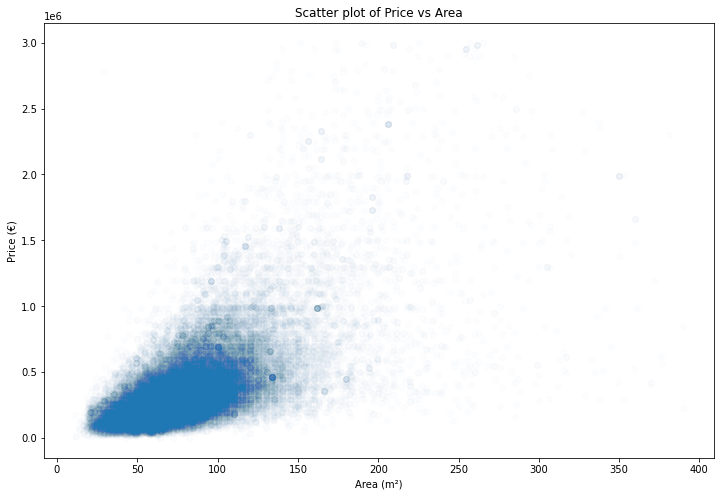

In [89]:
import matplotlib.pyplot as plt

subset = df[~df.area.isna() & ~df.price.isna()][["price", "area","distribution_type", "city", "state", "estate_type"]]
subset = subset[subset["distribution_type"]  == "Buy"]
subset = subset[subset["estate_type"]  == "apartment"]
subset = subset[subset["area"] < 400]
subset = subset[subset["price"] < 3000000]
plt.figure(figsize=(12, 8))
plt.scatter(subset["area"], subset["price"], alpha=0.01)
plt.xlabel("Area (m²)")
plt.ylabel("Price (€)")
plt.title("Scatter plot of Price vs Area")
plt.show()

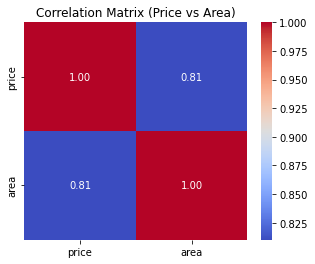

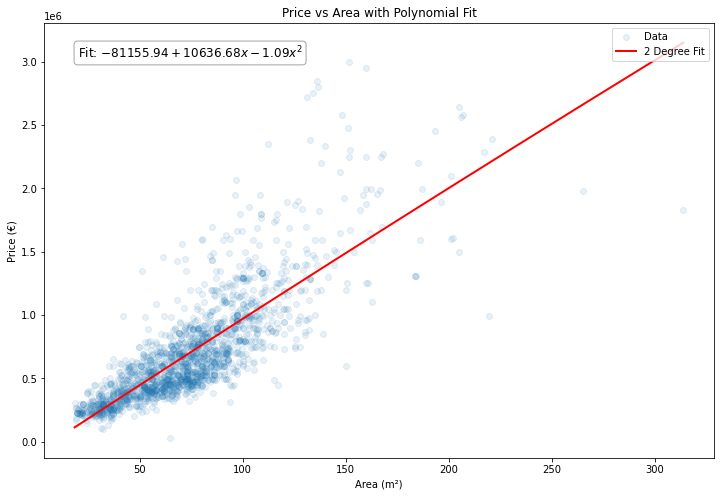

In [113]:
import seaborn as sns
from numpy.polynomial.polynomial import Polynomial

import matplotlib.pyplot as plt

subset2 = subset[subset["city"] == "München"]
# subset2 = subset.copy()

# Correlation matrix for numerical columns in subset
corr = subset2[["price", "area"]].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Price vs Area)")
plt.show()

# Fit a 2nd degree polynomial (quadratic) to price vs area
x = subset2["area"].values
y = subset2["price"].values
degree = 2
p = Polynomial.fit(x, y, degree)

# Scatter plot with polynomial fit
plt.figure(figsize=(12, 8))
plt.scatter(x, y, alpha=0.1, label="Data")
x_line = np.linspace(x.min(), x.max(), 200)
y_line = p(x_line)
plt.plot(x_line, y_line, color="red", linewidth=2, label=f"{degree} Degree Fit")

# Add polynomial equation as text on the plot
coefs = p.convert().coef  # Convert to power basis for readable coefficients
eqn = ""
for term in range(len(coefs)):
    if term == 0:
        eqn += f"{coefs[term]:.2f}"
    else:
        sign = "+" if coefs[term] >= 0 else "-"
        eqn += f" {sign} {abs(coefs[term]):.2f}x"
        if term > 1:
            eqn += f"^{term}"
eqn = f"${eqn}$"
plt.text(0.05, 0.95, f"Fit: {eqn}", transform=plt.gca().transAxes, fontsize=12,
         verticalalignment='top', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.7))
plt.xlabel("Area (m²)")
plt.ylabel("Price (€)")
plt.title("Price vs Area with Polynomial Fit")
plt.legend(loc="upper right")
plt.show()

In [114]:
def calculate_correlation_per_city(df, city):
    """
    Calculate the correlation between price and area for a specific city.
    """
    subset = df[(df["city"] == city) & (df["area"].notna()) & (df["price"].notna())]
    subset = subset[subset["distribution_type"] == "Buy"]
    if subset.empty:
        return None
    return subset[["price", "area"]].corr().iloc[0, 1]


most_common_cities = df["city"].value_counts().nlargest(20).index.tolist()
for city in most_common_cities:
    correlation = calculate_correlation_per_city(subset, city)
    print(f"Correlation between price and area in {city}: {correlation:.2f}")


Correlation between price and area in Berlin: 0.82
Correlation between price and area in Hamburg: 0.84
Correlation between price and area in München: 0.81
Correlation between price and area in Chemnitz: 0.62
Correlation between price and area in Nürnberg: 0.74
Correlation between price and area in Bremen: 0.82
Correlation between price and area in Dresden: 0.81
Correlation between price and area in Leipzig: 0.83
Correlation between price and area in Frankfurt am Main: 0.81
Correlation between price and area in Magdeburg: 0.69
Correlation between price and area in Köln: 0.77
Correlation between price and area in Essen: 0.81
Correlation between price and area in Dortmund: 0.74
Correlation between price and area in Düsseldorf: 0.82
Correlation between price and area in Hannover: 0.81
Correlation between price and area in Stuttgart: 0.83
Correlation between price and area in Duisburg: 0.75
Correlation between price and area in Fürth: 0.89
Correlation between price and area in Erlangen: 0.5

In [129]:
def calculate_fit(df, city, degree=2):
    """
    Calculate the polynomial fit for price vs area for a specific city.
    """
    subset = df[(df["city"] == city) & (df["area"].notna()) & (df["price"].notna())]
    subset = subset[subset["distribution_type"] == "Buy"]
    if subset.empty:
        return None
    x = subset["area"].values
    y = subset["price"].values

    # Remove outliers using the IQR method before fitting
    q1 = subset["price"].quantile(0.25)
    q3 = subset["price"].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    subset = subset[(subset["price"] >= lower_bound) & (subset["price"] <= upper_bound)]

    if subset.empty:
        return None
    x = subset["area"].values
    y = subset["price"].values
    p = Polynomial.fit(x, y, degree)
    return p

p = calculate_fit(df, "Düsseldorf", 2)
p(130).round(2)

687004.04

In [ ]:
df.query("distribution_type == 'Buy' and estate_type == 'apartment'") \
    .groupby("city").area.mean().round(2).sort_values(ascending=False).to_dict()["Düsseldorf"]

83.86

<AxesSubplot: ylabel='Frequency'>

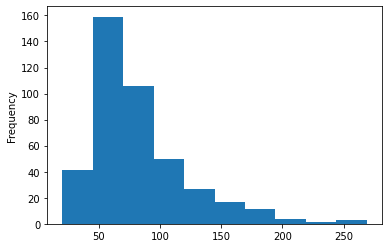

In [93]:
subset2["area"].plot(kind='hist')

In [32]:
headers = {
    "authority": "www.funda.nl",
    "accept": "text/html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.7",
    "accept-encoding": "gzip, deflate, br, zstd",
    "accept-language": "de-DE,de;q=0.9,en-US;q=0.8,en;q=0.7,tr;q=0.6,hu;q=0.5",
    "cache-control": "no-cache",
    "pragma": "no-cache",
    "priority": "u=0, i",
    "referer": "https://www.funda.nl/en/",
    "sec-ch-ua": '"Chromium";v="146", "Not-A.Brand";v="24", "Google Chrome";v="146"',
    "sec-ch-ua-mobile": "?1",
    "sec-ch-ua-platform": '"Android"',
    "sec-fetch-dest": "document",
    "sec-fetch-mode": "navigate",
    "sec-fetch-site": "same-origin",
    "sec-fetch-user": "?1",
    "upgrade-insecure-requests": "1",
    "user-agent": "Mozilla/5.0 (Linux; Android 6.0; Nexus 5 Build/MRA58N) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Mobile Safari/537.36",
}

url = 'https://www.funda.nl/en/zoeken/koop?selected_area=[%22den-haag%22]'
import requests
from bs4 import BeautifulSoup
r = requests.get(url, headers=headers)

In [33]:
soup = BeautifulSoup(r.text, 'lxml')

<!DOCTYPE html>
<html class="" dir="ltr" lang="en-US" style=""><head><meta charset="utf-8"/><meta content="width=device-width, initial-scale=1" name="viewport"/><title>Homes for sale  - houses for sale in  | Funda</title><link href="https://assets.fstatic.nl" rel="preconnect"/><link href="https://nuxt.fstatic.nl" rel="preconnect"/><link href="https://cloud.funda.nl" rel="preconnect"/><style>[data-reka-popper-content-wrapper][data-v-939fc7c4]{transform:none!important}</style><style>@media(prefers-reduced-motion:no-preference){.accordion-content[data-state=open][data-v-bcb49471]{animation:accordion-content-open-bcb49471 .5s var(--ease-in-out-soft)}.accordion-content[data-state=closed][data-v-bcb49471]{animation:accordion-content-close-bcb49471 .5s var(--ease-in-out-soft)}}@keyframes accordion-content-open-bcb49471{0%{height:0;opacity:0;transform:scaleY(.97) scaleX(1.02)}to{height:var(--reka-accordion-content-height);opacity:1;transform:scaleY(1) scaleX(1)}}@keyframes accordion-content-cl
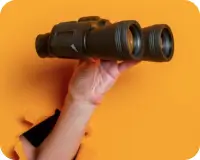

In [34]:
soup

In [38]:
soup.find('script', {'id' : '__NUXT_DATA__'}).text

'[["ShallowReactive",1],{"data":2,"state":5,"once":70,"_errors":71,"serverRendered":4,"path":73,"pinia":74},["ShallowReactive",3],{"fetchListings":4},true,["Reactive",6],{"$si18n:cached-locale-configs":7,"$si18n:resolved-locale":12,"$sfunda.shell.state.auth.token-set":-1,"$spage-view-id":13,"$sfunda.shell.state.auth.user":-1,"$shasConsumedSaveSearchQuery":14,"$sfavourites-saved-7959731":-1,"$sfavourites-pending-7959731":14,"$sblinkvanger-brokers-7959664":15,"$sfavourites-saved-7959664":-1,"$sfavourites-pending-7959664":14,"$sblinkvanger-brokers-7959661":22,"$sfavourites-saved-7959661":-1,"$sfavourites-pending-7959661":14,"$sfavourites-saved-7959364":-1,"$sfavourites-pending-7959364":14,"$sblinkvanger-brokers-7959358":28,"$sfavourites-saved-7959358":-1,"$sfavourites-pending-7959358":14,"$sfavourites-saved-7959126":-1,"$sfavourites-pending-7959126":14,"$sfavourites-saved-7959013":-1,"$sfavourites-pending-7959013":14,"$sblinkvanger-brokers-7958951":35,"$sfavourites-saved-7958951":-1,"$sfa

In [40]:
soup.find_all('div', class_='mt-2')

[<div class="mt-2"><div class="flex gap-2"><!-- --><div class="font-semibold"><!-- --><div class="truncate">€ 325,000 k.k.</div></div></div><div class="flex gap-3"><ul class="flex flex-wrap gap-3 gap-y-2 truncate overflow-hidden py-1"><li class="flex items-center"><svg class="mr-1" fill="currentColor" height="24" role="presentation" viewbox="0 0 48 48" width="24" xmlns="http://www.w3.org/2000/svg"><path d="M38.5 32.25v-16.5a5 5 0 10-6.25-6.25h-16.5a5 5 0 10-6.25 6.25v16.5a5 5 0 106.25 6.25h16.5a5 5 0 106.25-6.25zm-6.25 3.25h-16.5a5 5 0 00-3.25-3.25v-16.5a5 5 0 003.25-3.25h16.5a5 5 0 003.25 3.25v16.5a5 5 0 00-3.25 3.25zM37 9a2 2 0 11-2 2 2 2 0 012-2zM11 9a2 2 0 11-2 2 2 2 0 012-2zm0 30a2 2 0 112-2 2 2 0 01-2 2zm26 0a2 2 0 112-2 2 2 0 01-2 2z"></path></svg><span>67 m²</span></li><!-- --><li class="flex items-center"><svg class="mr-1" fill="currentColor" height="24" role="presentation" viewbox="0 0 48 48" width="24" xmlns="http://www.w3.org/2000/svg"><path d="M11 20l-3.999 5.999h33.998L37